In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
from sklearn.feature_selection import VarianceThreshold
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer

In [2]:
files_2017 = glob.glob("../data/raw/2017/*.csv")
print(f"Fichiers trouvés : {len(files_2017)}") 

df_2017 = pd.concat([pd.read_csv(f, low_memory=False) for f in files_2017], ignore_index=True)
df_2017.columns = df_2017.columns.str.strip()
df_2017.head()

Fichiers trouvés : 8


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [3]:
print(df_2017.shape)
print(df_2017.dtypes.value_counts())

(2830743, 79)
int64      54
float64    24
str         1
Name: count, dtype: int64


In [4]:
df_2017.isna().sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64

In [5]:
df_2017.replace([np.inf, -np.inf], np.nan, inplace=True)
nan_after = df_2017.isna().sum()
print(nan_after[nan_after > 0])
print(f"\nTotal lignes avant : {len(df_2017)}")

Flow Bytes/s      2867
Flow Packets/s    2867
dtype: int64

Total lignes avant : 2830743


In [6]:
df_2017.dropna(inplace=True)
print(f"Total lignes après  : {len(df_2017)}")

Total lignes après  : 2827876


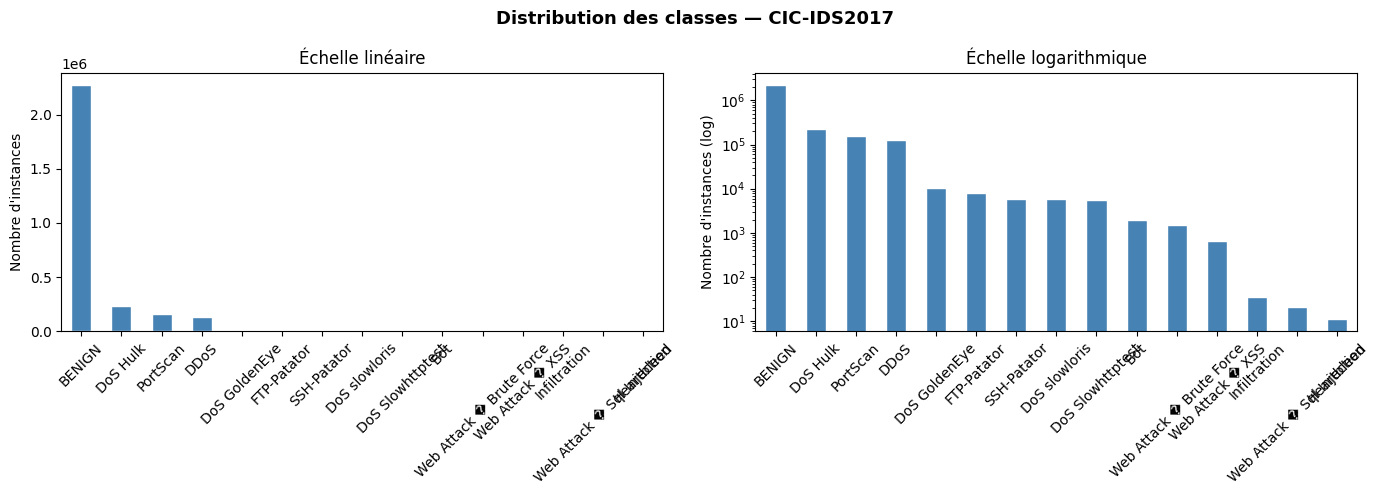

In [7]:
label_counts = df_2017["Label"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution des classes — CIC-IDS2017", fontsize=13, fontweight="bold")

label_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Échelle linéaire")
axes[0].set_xlabel("")
axes[0].set_ylabel("Nombre d'instances")
axes[0].tick_params(axis="x", rotation=45)

label_counts.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="white", logy=True)
axes[1].set_title("Échelle logarithmique")
axes[1].set_xlabel("")
axes[1].set_ylabel("Nombre d'instances (log)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [8]:
df_2017['Label'].unique()

<ArrowStringArray>
[                    'BENIGN',                       'DDoS',
                   'PortScan',                        'Bot',
               'Infiltration',   'Web Attack � Brute Force',
           'Web Attack � XSS', 'Web Attack � Sql Injection',
                'FTP-Patator',                'SSH-Patator',
              'DoS slowloris',           'DoS Slowhttptest',
                   'DoS Hulk',              'DoS GoldenEye',
                 'Heartbleed']
Length: 15, dtype: str

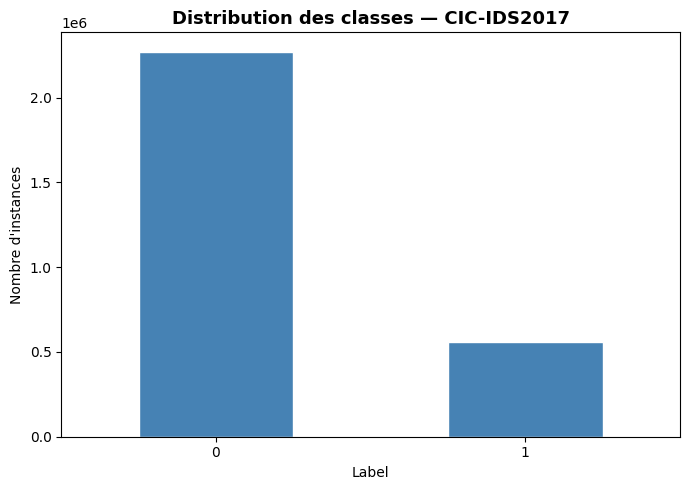

In [9]:
df_2017["Label"] = df_2017["Label"].map(lambda x: 0 if x == "BENIGN" or x == 0 else 1)

label_counts = df_2017["Label"].value_counts()

plt.figure(figsize=(7, 5))

label_counts.plot(
    kind="bar",
    color="steelblue",
    edgecolor="white"
)

plt.title("Distribution des classes — CIC-IDS2017", fontsize=13, fontweight="bold")
plt.ylabel("Nombre d'instances")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [10]:
df_2017.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [11]:
df_2017.drop(columns=["Fwd Header Length.1"], inplace=True)

In [12]:
selector = VarianceThreshold(threshold=0)
selector.fit(df_2017.drop(columns=["Label"]))

zero_var_cols = df_2017.drop(columns=["Label"]).columns[~selector.get_support()].tolist()
print(f"Features variance nulle : {zero_var_cols}")

Features variance nulle : ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [13]:
df_2017.drop(columns=zero_var_cols, inplace=True)

In [14]:
corr_matrix = df_2017.drop(columns=["Label"]).corr().abs()

corr_with_target = df_2017.corr(numeric_only=True)["Label"].abs()

to_drop = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.98:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]

            if corr_with_target[col_i] < corr_with_target[col_j]:
                to_drop.add(col_i)
            else:
                to_drop.add(col_j)
                
print(to_drop)

{'Average Packet Size', 'RST Flag Count', 'Total Length of Fwd Packets', 'Fwd Packets/s', 'Total Length of Bwd Packets', 'Total Fwd Packets', 'Idle Min', 'Subflow Bwd Bytes', 'Fwd URG Flags', 'Fwd PSH Flags', 'Idle Mean', 'Max Packet Length', 'Total Backward Packets', 'Fwd IAT Max', 'Flow IAT Max', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Bwd Packet Length Max', 'Flow Duration', 'Fwd Packet Length Mean'}


In [15]:
df_2017.drop(columns=to_drop,inplace=True)

In [16]:
X = df_2017.drop(columns=["Label"])
y = df_2017["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Train : (2262300, 49) | Test : (565576, 49)


In [17]:
qt = QuantileTransformer(output_distribution='normal',n_quantiles=50000,subsample=None,random_state=42)
X_scaled_train = pd.DataFrame(qt.fit_transform(X_train), columns=X.columns)
X_scaled_test = pd.DataFrame(qt.transform(X_test), columns=X.columns)

In [18]:
X_scaled_train["Label"] = y_train.values
X_scaled_test["Label"] = y_test.values

X_scaled_train.to_csv("../data/processed/2017/2017_train_scaled.csv", index=False)
X_scaled_test.to_csv("../data/processed/2017/2017_test_scaled.csv", index=False)

print(f"Train sauvegardé : {X_scaled_train.shape}")
print(f"Test sauvegardé  : {X_scaled_test.shape}")

Train sauvegardé : (2262300, 50)
Test sauvegardé  : (565576, 50)
